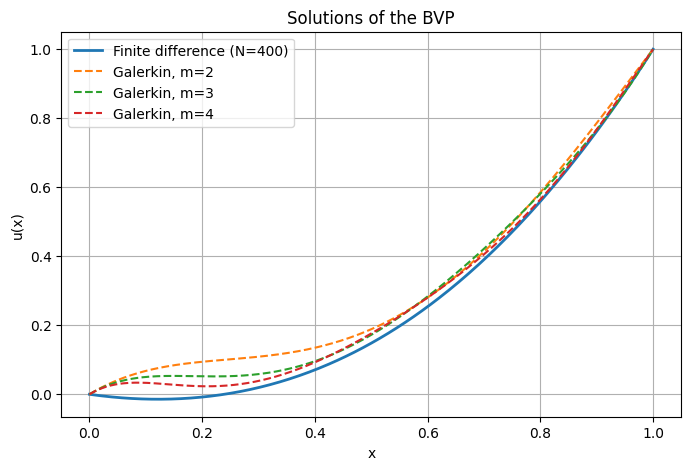

0: {'Method': 'Galerkin m=2', 'max|error| vs FD': np.float64(0.10224952227062216)}
1: {'Method': 'Galerkin m=3', 'max|error| vs FD': np.float64(0.06717671869752086)}
2: {'Method': 'Galerkin m=4', 'max|error| vs FD': np.float64(0.04707157172828435)}
3: {'Method': 'FD (N=400)', 'max|error| vs FD': 0.0}


In [7]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import quad

# -------------------------------
# 1. Galerkin method
# -------------------------------

x = sp.symbols('x')


def galerkin_solution(num_basis=2):
    """
    Return a callable u_gal(x) – Galerkin approximation with `num_basis`
    basis functions for the BVP

        u'' - u' + x u = 2,  0<=x<=1,  u(0)=0, u(1)=1
    """
    # particular function w(x) that satisfies the boundary conditions
    w = x  # w(0)=0, w(1)=1

    # basis functions φ_i = x (1-x) P_i(x), where P_i = x^i
    basis = [x * (1 - x) * x ** i for i in range(1, num_basis + 1)]

    # unknown coefficients
    c = sp.symbols(f'c0:{num_basis}')

    # trial solution
    u_trial = w + sum(ci * phi for ci, phi in zip(c, basis))

    # residual R = L[u_trial] - 2
    R = sp.diff(u_trial, x, 2) - sp.diff(u_trial, x) + x * u_trial - 2

    # Galerkin conditions: ∫_0^1 R φ_j dx = 0
    equations = []
    for phi_j in basis:
        integrand = sp.integrate(R * phi_j, (x, 0, 1))
        equations.append(sp.Eq(integrand, 0))

    # solve for coefficients
    sol = sp.solve(equations, c, dict=True)[0]
    u_gal = sp.lambdify(x, u_trial.subs(sol), 'numpy')
    return u_gal


# -------------------------------
# 2. Finite‑difference solution
# -------------------------------

def fd_solution(N=100):
    """
    Solve the BVP by central‑difference + Thomas algorithm
    on N uniform segments (N+1 nodes).
    """
    h = 1.0 / N
    x_nodes = np.linspace(0, 1, N + 1)

    a = np.zeros(N - 1)  # sub‑diagonal
    b = np.zeros(N - 1)  # main
    c = np.zeros(N - 1)  # super‑diagonal
    d = np.zeros(N - 1)  # RHS

    for i in range(1, N):
        xi = x_nodes[i]
        a_i = 1 + h / 2          # coeff for u_{i-1}
        b_i = -2 + xi * h ** 2   # coeff for u_i
        c_i = 1 - h / 2          # coeff for u_{i+1}
        d_i = 2 * h ** 2         # RHS

        a[i - 1] = a_i
        b[i - 1] = b_i
        c[i - 1] = c_i
        d[i - 1] = d_i

    # modify RHS to include Dirichlet BC
    d[0] -= a[0] * 0.0          # u_0 = 0
    d[-1] -= c[-1] * 1.0        # u_N = 1
    a[0] = 0.0
    c[-1] = 0.0

    # Thomas algorithm
    # forward sweep
    for i in range(1, N - 1):
        m = a[i] / b[i - 1]
        b[i] = b[i] - m * c[i - 1]
        d[i] = d[i] - m * d[i - 1]

    # back substitution
    u_internal = np.zeros(N - 1)
    u_internal[-1] = d[-1] / b[-1]
    for i in reversed(range(N - 2)):
        u_internal[i] = (d[i] - c[i] * u_internal[i + 1]) / b[i]

    # full solution with boundary values
    u = np.zeros(N + 1)
    u[0] = 0.0
    u[-1] = 1.0
    u[1:N] = u_internal
    return x_nodes, u


# -------------------------------
# 3. Demonstration
# -------------------------------

# Galerkin approximations with 2,3,4 basis functions
gal_funcs = {n: galerkin_solution(n) for n in (2, 3, 4)}

# Finite‑difference reference (dense mesh)
x_fd, u_fd = fd_solution(400)

# Plot
x_plot = np.linspace(0, 1, 400)
plt.figure(figsize=(8, 5))
plt.plot(x_fd, u_fd, label='Finite difference (N=400)', linewidth=2)
for n, f in gal_funcs.items():
    plt.plot(x_plot, f(x_plot), '--', label=f'Galerkin, m={n}')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Solutions of the BVP')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 4. Error analysis table
# -------------------------------

import pandas as pd

rows = []
for n, f in gal_funcs.items():
    err = np.abs(f(x_fd) - u_fd).max()
    rows.append({'Method': f'Galerkin m={n}', 'max|error| vs FD': err})
rows.append({'Method': 'FD (N=400)', 'max|error| vs FD': 0.0})
for i in range(len(rows)):
    print(f'{i}: {rows[i]}')
